<a href="https://colab.research.google.com/github/montesquieu891/analisis_nacimientos_2018_2019/blob/main/analisis_nacimientos_2018_2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nacimientos 2018–2019: del dato a la teoría de probabilidad

**Objetivo del trabajo:** contrastar el modelo teórico de nacimientos uniformemente distribuidos a lo largo del año (`P(fecha) = 1/365`) contra los datos reales de nacimientos de 2018 y 2019, y usar esa comparación para construir formalmente un espacio de probabilidad `(Ω, ℱ, P)`.

**Datasets:**
- `nacimientos_2018.xlsx`: registros individuales de nacimientos del año 2018.
- `nacimientos_2019.csv`: registros individuales de nacimientos del año 2019.

Este notebook está pensado para correr de punta a punta en Google Colab, sin ediciones manuales, siempre que los dos archivos estén disponibles en el entorno de ejecución.

## 1. Introducción

Una creencia intuitiva bastante extendida es que los nacimientos se distribuyen de manera pareja a lo largo de los 365 días del año: bajo esa hipótesis, cualquier fecha tendría la misma probabilidad de albergar un nacimiento (`1/365 ≈ 0,274%`).

En este trabajo vamos a:

1. Cargar e inspeccionar los datos reales de nacimientos de 2018 y 2019.
2. Explorar cómo se distribuyen los nacimientos por mes, por día del año y por fecha puntual.
3. Visualizar esos patrones y buscar indicios de desviaciones sistemáticas respecto del modelo uniforme (por ejemplo, efectos de fin de semana).
4. Formalizar el problema como un espacio de probabilidad `(Ω, ℱ, P)`, distinguiendo probabilidad teórica de probabilidad empírica.
5. Sacar conclusiones sobre qué tan razonable es el supuesto de uniformidad.

Todo el análisis se apoya exclusivamente en lo que muestran los dos archivos adjuntos.

In [1]:
# Librerías utilizadas en todo el notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_rows', 20)
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Carga e inspección de los datos

Antes de asumir nombres de columnas o formatos, cargamos ambos archivos y los inspeccionamos por separado. La celda siguiente contempla que el notebook corra tanto en Google Colab (permitiendo subir los archivos si no están presentes) como en un entorno local donde los archivos ya estén en el mismo directorio.

In [2]:
import os

archivo_2018 = 'nacimientos_2018.xlsx'
archivo_2019 = 'nacimientos_2019.csv'

try:
    import google.colab  # noqa: F401
    en_colab = True
except ImportError:
    en_colab = False

if en_colab and not (os.path.exists(archivo_2018) and os.path.exists(archivo_2019)):
    from google.colab import files
    print('Subí los archivos nacimientos_2018.xlsx y nacimientos_2019.csv:')
    files.upload()

df_2018 = pd.read_excel(archivo_2018)
df_2019 = pd.read_csv(archivo_2019)

print('2018 -> filas:', df_2018.shape[0], '| columnas:', df_2018.shape[1])
print('2019 -> filas:', df_2019.shape[0], '| columnas:', df_2019.shape[1])

2018 -> filas: 67633 | columnas: 2
2019 -> filas: 41217 | columnas: 3


In [3]:
print('--- Columnas y tipos: 2018 ---')
print(df_2018.dtypes, '\n')
print('--- Columnas y tipos: 2019 ---')
print(df_2019.dtypes)

--- Columnas y tipos: 2018 ---
fecha_nacimiento    object
genero_nacido       object
dtype: object 

--- Columnas y tipos: 2019 ---
fecha_nacimiento       object
genero_nacido          object
descripcion_subtipo    object
dtype: object


In [4]:
print('--- Primeros registros 2018 ---')
display(df_2018.head())
print('\n--- Primeros registros 2019 ---')
display(df_2019.head())

--- Primeros registros 2018 ---


,fecha_nacimiento,genero_nacido
0,2018-01-01,Femenino
1,2018-01-01,Masculino
2,2018-01-01,Femenino
3,2018-01-01,Femenino
4,2018-01-01,Masculino



--- Primeros registros 2019 ---


,fecha_nacimiento,genero_nacido,descripcion_subtipo
0,2019-01-01,Masculino,Extramatrimonial con Padre
1,2019-01-01,Masculino,Extramatrimonial con Padre
2,2019-01-01,Masculino,Extramatrimonial con Padre
3,2019-01-01,Masculino,Matrimonial
4,2019-01-01,Femenino,Extramatrimonial con Padre


In [6]:
print('Valores faltantes 2018:')
print(df_2018.isna().sum(), '\n')
print('Valores faltantes 2019:')
print(df_2019.isna().sum())

print('\nFilas totalmente duplicadas en 2018:', df_2018.duplicated().sum())
print('Filas totalmente duplicadas en 2019:', df_2019.duplicated().sum())

Valores faltantes 2018:
fecha_nacimiento    0
genero_nacido       0
dtype: int64 

Valores faltantes 2019:
fecha_nacimiento       0
genero_nacido          0
descripcion_subtipo    0
dtype: int64

Filas totalmente duplicadas en 2018: 66903
Filas totalmente duplicadas en 2019: 39464


**Nota sobre las filas "duplicadas":** ambos datasets no tienen un identificador único por nacimiento; cada fila es un registro individual de nacimiento con columnas como fecha y género. Es esperable que muchas filas compartan exactamente los mismos valores (misma fecha, mismo género) porque corresponden a nacimientos distintos ocurridos el mismo día, no a errores de carga. No se eliminan estas filas.

In [7]:
# Conversión de fechas y columnas derivadas
df_2018['fecha_nacimiento'] = pd.to_datetime(df_2018['fecha_nacimiento'])
df_2019['fecha_nacimiento'] = pd.to_datetime(df_2019['fecha_nacimiento'])

for df in (df_2018, df_2019):
    df['anio'] = df['fecha_nacimiento'].dt.year
    df['mes'] = df['fecha_nacimiento'].dt.month
    df['dia_anio'] = df['fecha_nacimiento'].dt.dayofyear
    df['dia_semana'] = df['fecha_nacimiento'].dt.dayofweek  # 0=lunes ... 6=domingo
    df['es_fin_de_semana'] = df['dia_semana'] >= 5

print('Rango de fechas 2018:', df_2018['fecha_nacimiento'].min().date(), '-', df_2018['fecha_nacimiento'].max().date())
print('Rango de fechas 2019:', df_2019['fecha_nacimiento'].min().date(), '-', df_2019['fecha_nacimiento'].max().date())

print('\nFechas distintas con al menos un nacimiento en 2018:', df_2018['fecha_nacimiento'].nunique())
print('Fechas distintas con al menos un nacimiento en 2019:', df_2019['fecha_nacimiento'].nunique())

Rango de fechas 2018: 2018-01-01 - 2018-12-31
Rango de fechas 2019: 2019-01-01 - 2019-08-31

Fechas distintas con al menos un nacimiento en 2018: 365
Fechas distintas con al menos un nacimiento en 2019: 243


In [9]:
# ¿Faltan días del calendario dentro del rango observado en cada dataset?
rango_2018 = pd.date_range(df_2018['fecha_nacimiento'].min(), df_2018['fecha_nacimiento'].max())
faltantes_2018 = sorted(set(rango_2018) - set(df_2018['fecha_nacimiento'].unique()))

rango_2019_completo = pd.date_range('2019-01-01', '2019-12-31')
faltantes_2019_anio_completo = sorted(set(rango_2019_completo) - set(df_2019['fecha_nacimiento'].unique()))

print('Días sin ningún nacimiento dentro del rango 2018:', len(faltantes_2018))
print('Días del año calendario 2019 sin registros en el dataset:', len(faltantes_2019_anio_completo))
print('Primer y último día faltante en 2019:', faltantes_2019_anio_completo[0].date(), '/', faltantes_2019_anio_completo[-1].date())

Días sin ningún nacimiento dentro del rango 2018: 0
Días del año calendario 2019 sin registros en el dataset: 122
Primer y último día faltante en 2019: 2019-09-01 / 2019-12-31


**Hallazgo clave de la inspección — cobertura desigual entre años:**

- `nacimientos_2018.xlsx` cubre el año calendario completo: 365 fechas distintas, sin días faltantes entre el 1 de enero y el 31 de diciembre de 2018, y sin valores nulos.
- `nacimientos_2019.csv` **solo contiene registros desde el 1 de enero hasta el 31 de agosto de 2019** (243 fechas distintas). No hay ningún nacimiento cargado para septiembre–diciembre de 2019 dentro del archivo. Esto **no** se interpreta como "cero nacimientos reales" en esos meses, sino como datos no disponibles en el archivo entregado.
- Además, `nacimientos_2019.csv` tiene una columna adicional (`descripcion_subtipo`, tipo de filiación) que no está en el archivo de 2018, y la columna de género tiene más categorías en 2019 (incluye `No declara` e `Indefinido`) además de `Femenino`/`Masculino`.

**Consecuencia metodológica:** cualquier comparación directa entre 2018 y 2019 en términos de *totales anuales* o *porcentaje sobre el total del año* estaría sesgada, porque 2019 solo tiene información de 8 de los 12 meses. Para que las comparaciones sean justas, en este notebook:

- Los análisis de cada año **por separado** (por ejemplo, meses con más/menos nacimientos, picos por día) se calculan sobre los datos realmente disponibles de ese año.
- Las comparaciones **entre 2018 y 2019** se restringen al período común (enero–agosto, días 1 a 243 del año) o se expresan como promedios por día en vez de totales, para que la duración distinta de cada serie no distorsione la conclusión.

## 3. Análisis exploratorio

### 3.A Nacimientos por mes

Agrupamos los nacimientos por mes calendario. Dado que 2019 solo tiene ocho meses de datos, mostramos primero cada año con su propio total (para no repetir el sesgo de cobertura) y agregamos el promedio de nacimientos por día del mes, que sí es comparable entre años y entre meses de distinta longitud.

In [10]:
def tabla_por_mes(df, etiqueta):
    conteo = df.groupby('mes').size().rename('nacimientos')
    dias_con_datos = df.groupby('mes')['fecha_nacimiento'].nunique().rename('dias_con_datos')
    tabla = pd.concat([conteo, dias_con_datos], axis=1)
    tabla['pct_sobre_total_%'] = (tabla['nacimientos'] / tabla['nacimientos'].sum() * 100).round(2)
    tabla['prom_nacimientos_x_dia'] = (tabla['nacimientos'] / tabla['dias_con_datos']).round(1)
    tabla.index.name = f'mes_{etiqueta}'
    return tabla

tabla_2018 = tabla_por_mes(df_2018, '2018')
tabla_2019 = tabla_por_mes(df_2019, '2019')

print('--- 2018 (año completo) ---')
display(tabla_2018)
print('\n--- 2019 (solo ene-ago, datos disponibles) ---')
display(tabla_2019)

--- 2018 (año completo) ---


,nacimientos,dias_con_datos,pct_sobre_total_%,prom_nacimientos_x_dia
mes_2018,,,,
1,5863,31,8.67,189.1
2,5399,28,7.98,192.8
3,6011,31,8.89,193.9
4,5833,30,8.62,194.4
5,5963,31,8.82,192.4
6,5526,30,8.17,184.2
7,5540,31,8.19,178.7
8,5842,31,8.64,188.5
9,5348,30,7.91,178.3



--- 2019 (solo ene-ago, datos disponibles) ---


,nacimientos,dias_con_datos,pct_sobre_total_%,prom_nacimientos_x_dia
mes_2019,,,,
1,5351,31,12.98,172.6
2,5004,28,12.14,178.7
3,5521,31,13.39,178.1
4,5379,30,13.05,179.3
5,5286,31,12.82,170.5
6,4990,30,12.11,166.3
7,5143,31,12.48,165.9
8,4543,31,11.02,146.5


In [11]:
mes_max_2018 = tabla_2018['nacimientos'].idxmax()
mes_min_2018 = tabla_2018['nacimientos'].idxmin()
mes_max_2019 = tabla_2019['nacimientos'].idxmax()
mes_min_2019 = tabla_2019['nacimientos'].idxmin()

print(f"2018 -> mes con más nacimientos: {mes_max_2018} ({tabla_2018.loc[mes_max_2018,'nacimientos']}); "
      f"mes con menos: {mes_min_2018} ({tabla_2018.loc[mes_min_2018,'nacimientos']})")
print(f"2019 (ene-ago) -> mes con más nacimientos: {mes_max_2019} ({tabla_2019.loc[mes_max_2019,'nacimientos']}); "
      f"mes con menos: {mes_min_2019} ({tabla_2019.loc[mes_min_2019,'nacimientos']})")

2018 -> mes con más nacimientos: 3 (6011); mes con menos: 12 (5270)
2019 (ene-ago) -> mes con más nacimientos: 3 (5521); mes con menos: 8 (4543)


**Interpretación:** en 2018, marzo concentra la mayor cantidad de nacimientos (6.011, 8,89% del año) y diciembre la menor (5.270, 7,79%). En 2019 (considerando solo enero–agosto, que es todo lo que hay en el archivo), marzo vuelve a ser el mes con más nacimientos (5.521) y agosto el de menos (4.543); sin embargo, agosto de 2019 muestra un promedio de nacimientos por día notablemente más bajo que el resto de los meses de ese mismo año (~146,5 frente a valores de 165–180 en los demás meses). Al revisar el detalle diario, se observa una caída progresiva hacia el 31 de agosto (los últimos días del mes tienen conteos bajos, por ejemplo 73–101 nacimientos frente a valores de 150–190 en días previos). Esto es compatible con un efecto de **carga incompleta de los últimos registros cerca de la fecha de corte del archivo** (nacimientos que aún no habían sido cargados al sistema al momento de exportar los datos), pero los datos disponibles no permiten confirmarlo con certeza; se señala como una limitación a tener en cuenta y no como un patrón estacional real.

Con el promedio por día (que sí es comparable) y restringiendo a los meses en común, ambos años muestran un patrón mensual similar: valores más altos en marzo–mayo y más bajos hacia fin de año o en el mes con datos incompletos.

### 3.B Nacimientos por día del año

Usamos el **día del año** (`dayofyear`: 1 a 365/366) en vez de la fecha calendario para poder comparar directamente el mismo punto del año entre 2018 y 2019, sin que el día de la semana en el que cae una fecha específica (que cambia de un año a otro) mezcle ambas cosas. Como ninguno de los dos años es bisiesto, el día del año va de 1 a 365 en ambos casos (2019 solo tiene datos hasta el día 243, que corresponde al 31 de agosto).

In [12]:
nac_por_dia_2018 = df_2018.groupby('dia_anio').size()
nac_por_dia_2019 = df_2019.groupby('dia_anio').size()

print('2018 -> nacimientos por día del año: mínimo', nac_por_dia_2018.min(),
      '| máximo', nac_por_dia_2018.max(), '| promedio', round(nac_por_dia_2018.mean(), 1))
print('2019 (días 1-243) -> mínimo', nac_por_dia_2019.min(),
      '| máximo', nac_por_dia_2019.max(), '| promedio', round(nac_por_dia_2019.mean(), 1))

print('\nTop 10 días del año 2018 con más nacimientos:')
display(nac_por_dia_2018.sort_values(ascending=False).head(10))

print('\nTop 10 días del año 2019 con más nacimientos:')
display(nac_por_dia_2019.sort_values(ascending=False).head(10))

2018 -> nacimientos por día del año: mínimo 76 | máximo 270 | promedio 185.3
2019 (días 1-243) -> mínimo 73 | máximo 256 | promedio 169.6

Top 10 días del año 2018 con más nacimientos:


,0
dia_anio,
361,270
86,264
85,263
94,259
281,257
87,253
233,250
45,250
149,249



Top 10 días del año 2019 con más nacimientos:


,0
dia_anio,
65,256
105,245
70,237
66,236
52,230
28,225
112,224
107,224
93,224


**Interpretación:** en 2018 el pico absoluto está en el día 361 del año (270 nacimientos), pero varios de los días con más nacimientos se concentran a fines de marzo/principios de abril (días 85 a 94) y también en enero–febrero. En 2019 el pico está en el día 65 (256 nacimientos, correspondiente al 6 de marzo) y varios de los días más altos también caen en marzo–abril. Esto sugiere que, más allá del pico puntual más alto de cada año, hay una zona del calendario (fines de marzo/principios de abril) con nacimientos elevados en ambos años, lo cual es consistente con lo visto en el análisis mensual.

### 3.C Fechas de nacimiento con mayor cantidad de coincidencias

Acá miramos la fecha calendario puntual (no solo el "día del año") con más nacimientos registrados dentro de cada dataset.

**Aclaración importante:** que una fecha concentre muchos nacimientos significa que ese día se registraron muchos nacimientos *distintos* dentro del mismo dataset — no implica que existan personas que "coincidan" entre el archivo de 2018 y el de 2019 (son años distintos) ni que haya algún tipo de relación entre esos nacimientos más allá de compartir la fecha.

In [ ]:
top_fechas_2018 = df_2018.groupby('fecha_nacimiento').size().sort_values(ascending=False).head(10)
top_fechas_2019 = df_2019.groupby('fecha_nacimiento').size().sort_values(ascending=False).head(10)

print('Top 10 fechas con más nacimientos en 2018:')
display(top_fechas_2018)

print('\nTop 10 fechas con más nacimientos en 2019:')
display(top_fechas_2019)

Top 10 fechas con más nacimientos en 2018:


fecha_nacimiento
2018-12-27    270
2018-03-27    264
2018-03-26    263
2018-04-04    259
2018-10-08    257
2018-03-28    253
2018-02-14    250
2018-08-21    250
2018-05-29    249
2018-04-03    248
dtype: int64


Top 10 fechas con más nacimientos en 2019:


fecha_nacimiento
2019-03-06    256
2019-04-15    245
2019-03-11    237
2019-03-07    236
2019-02-21    230
2019-01-28    225
2019-04-22    224
2019-04-17    224
2019-04-03    224
2019-02-20    224
dtype: int64

**Interpretación:** la fecha con más nacimientos en 2018 es el 27/12/2018 (270 casos), seguida por varios días de fines de marzo de 2018 (26, 27 y 28/03). En 2019, la fecha con más nacimientos es el 06/03/2019 (256 casos), seguida por el 15/04 y el 11/03. Ninguna fecha se repite entre ambos rankings (son años distintos), lo cual es esperable. Lo relevante es que, en los dos años, varias de las fechas "pico" caen en marzo, reforzando el patrón detectado en 3.A y 3.B.

## 4. Visualización

### 4.1 Nacimientos por mes (2018 vs. 2019)

Se muestra el total de nacimientos por mes de cada año. Como 2019 solo tiene datos hasta agosto, sus barras posteriores a agosto directamente no existen (no se completan con cero para no sugerir que no hubo nacimientos, sino que no hay dato).

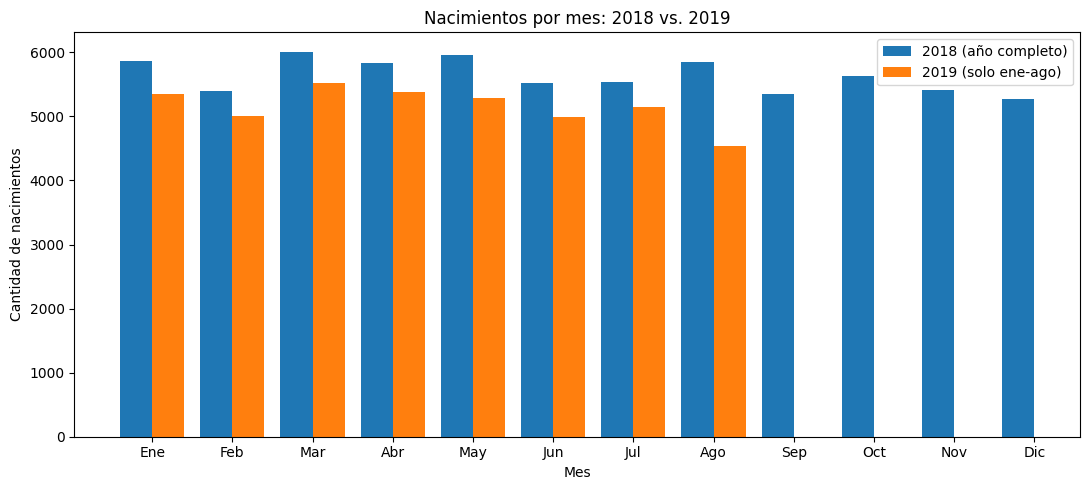

In [ ]:
meses_nombre = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(tabla_2018.index - 0.2, tabla_2018['nacimientos'], width=0.4, label='2018 (año completo)')
ax.bar(tabla_2019.index + 0.2, tabla_2019['nacimientos'], width=0.4, label='2019 (solo ene-ago)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nombre)
ax.set_xlabel('Mes')
ax.set_ylabel('Cantidad de nacimientos')
ax.set_title('Nacimientos por mes: 2018 vs. 2019')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Distribución de nacimientos por día del año — 2018

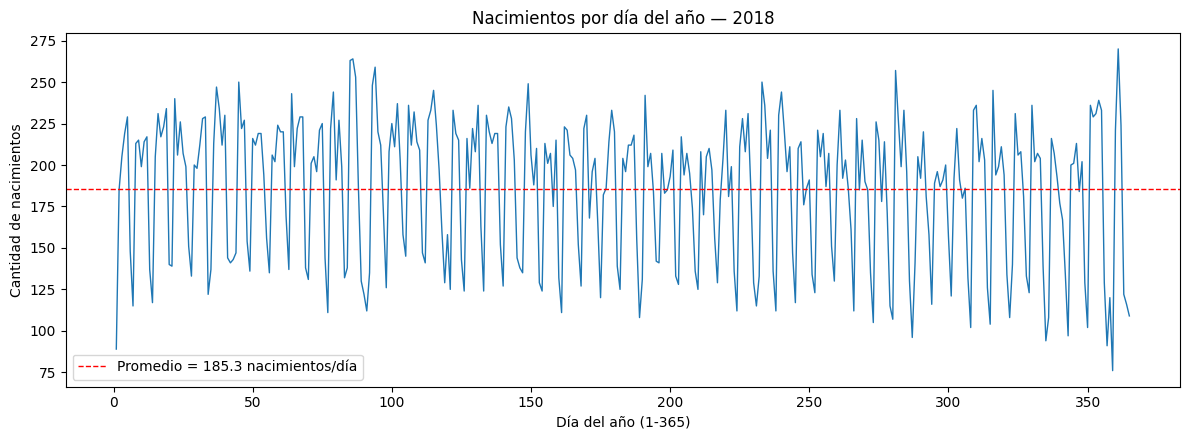

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(nac_por_dia_2018.index, nac_por_dia_2018.values, linewidth=1)
ax.axhline(nac_por_dia_2018.mean(), color='red', linestyle='--', linewidth=1,
           label=f'Promedio = {nac_por_dia_2018.mean():.1f} nacimientos/día')
ax.set_xlabel('Día del año (1-365)')
ax.set_ylabel('Cantidad de nacimientos')
ax.set_title('Nacimientos por día del año — 2018')
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Distribución de nacimientos por día del año — 2019

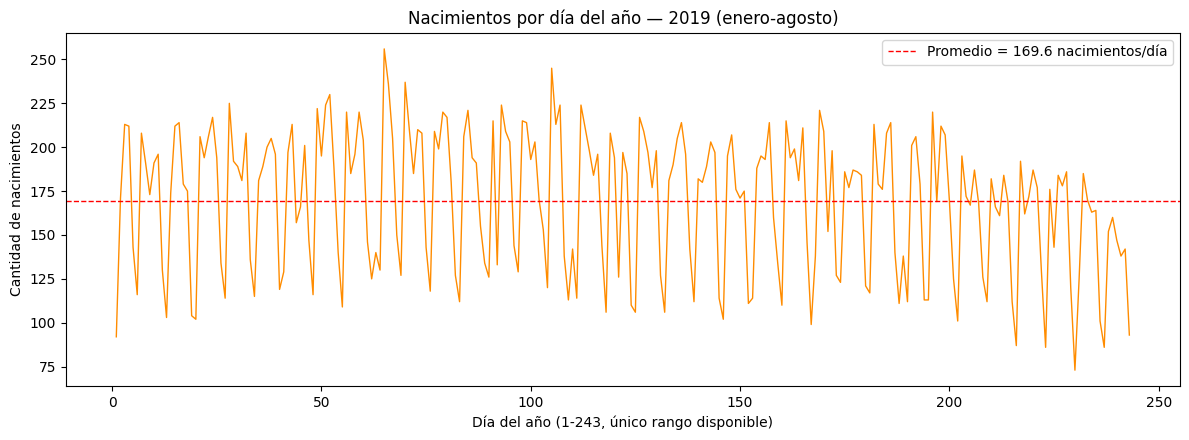

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(nac_por_dia_2019.index, nac_por_dia_2019.values, linewidth=1, color='darkorange')
ax.axhline(nac_por_dia_2019.mean(), color='red', linestyle='--', linewidth=1,
           label=f'Promedio = {nac_por_dia_2019.mean():.1f} nacimientos/día')
ax.set_xlabel('Día del año (1-243, único rango disponible)')
ax.set_ylabel('Cantidad de nacimientos')
ax.set_title('Nacimientos por día del año — 2019 (enero-agosto)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 Comparación 2018 vs. 2019 en el período común (días 1 a 243)

Para que la comparación sea válida, restringimos ambos años al mismo rango de días del año.

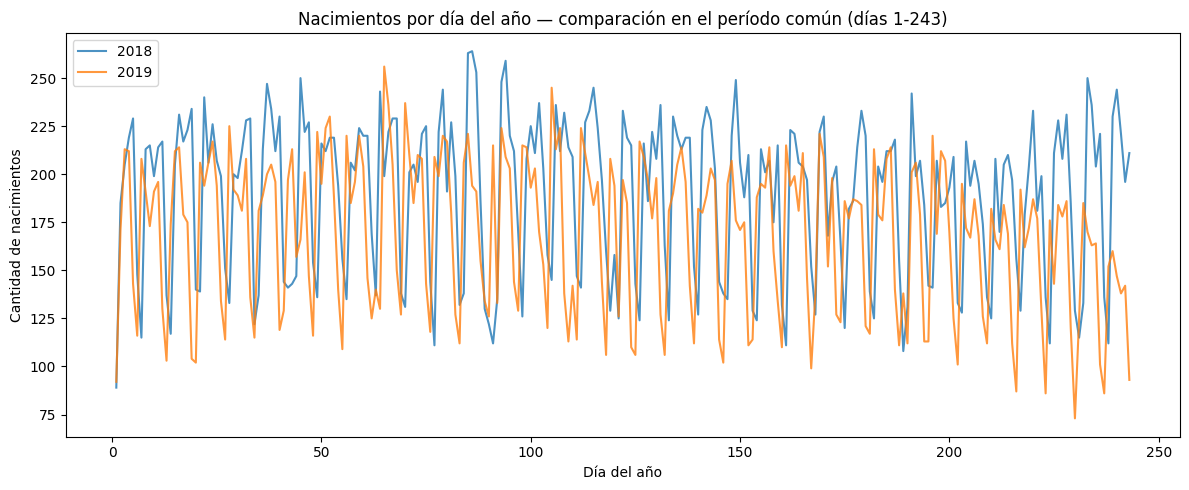

In [ ]:
dia_max_comun = nac_por_dia_2019.index.max()  # 243, límite real de 2019

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(nac_por_dia_2018.loc[:dia_max_comun].index,
        nac_por_dia_2018.loc[:dia_max_comun].values,
        label='2018', alpha=0.8)
ax.plot(nac_por_dia_2019.index, nac_por_dia_2019.values,
        label='2019', alpha=0.8)
ax.set_xlabel('Día del año')
ax.set_ylabel('Cantidad de nacimientos')
ax.set_title(f'Nacimientos por día del año — comparación en el período común (días 1-{dia_max_comun})')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación visual:** en ambos años se observa un patrón oscilante con caídas periódicas muy regulares (aproximadamente cada 7 días), en vez de una nube de puntos plana como esperaría el modelo uniforme. Este patrón sugiere un efecto asociado al día de la semana. Antes de afirmar que se trata de un efecto de "fin de semana", lo comprobamos directamente con los datos en la siguiente sección, en vez de asumirlo a partir del gráfico.

### 4.5 Nacimientos por día de la semana

Agrupamos por día de la semana (0 = lunes … 6 = domingo) para verificar si las caídas periódicas del gráfico anterior coinciden con los fines de semana.

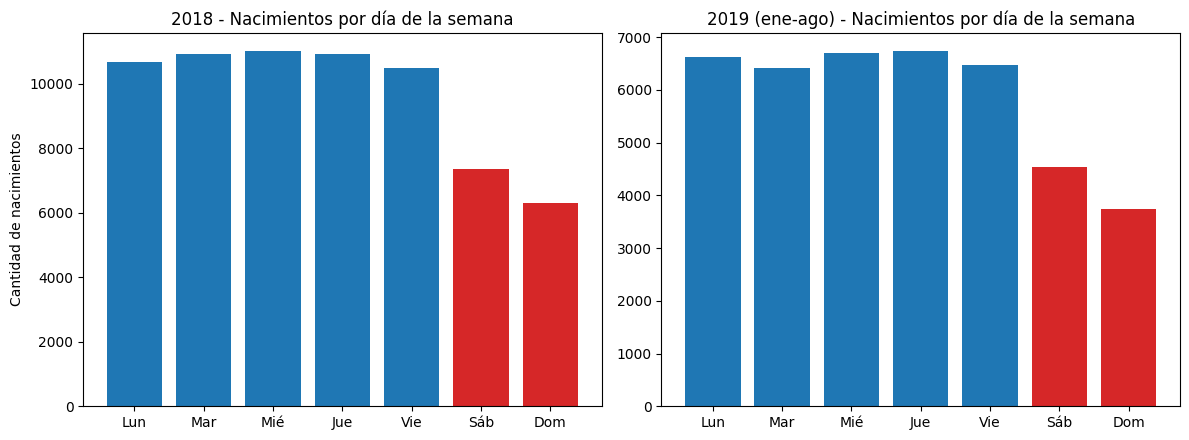

In [ ]:
dias_semana_nombre = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

nac_por_dia_semana_2018 = df_2018.groupby('dia_semana').size()
nac_por_dia_semana_2019 = df_2019.groupby('dia_semana').size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
colores = ['tab:blue']*5 + ['tab:red']*2

axes[0].bar(dias_semana_nombre, nac_por_dia_semana_2018.values, color=colores)
axes[0].set_title('2018 - Nacimientos por día de la semana')
axes[0].set_ylabel('Cantidad de nacimientos')

axes[1].bar(dias_semana_nombre, nac_por_dia_semana_2019.values, color=colores)
axes[1].set_title('2019 (ene-ago) - Nacimientos por día de la semana')

plt.tight_layout()
plt.show()

In [ ]:
def promedio_habil_finde(df):
    habiles = df.loc[~df['es_fin_de_semana']].groupby('fecha_nacimiento').size().mean()
    finde = df.loc[df['es_fin_de_semana']].groupby('fecha_nacimiento').size().mean()
    return round(habiles, 1), round(finde, 1)

prom_habil_2018, prom_finde_2018 = promedio_habil_finde(df_2018)
prom_habil_2019, prom_finde_2019 = promedio_habil_finde(df_2019)

print(f'2018 -> promedio nacimientos/día en día hábil: {prom_habil_2018} | en fin de semana: {prom_finde_2018}')
print(f'2019 -> promedio nacimientos/día en día hábil: {prom_habil_2019} | en fin de semana: {prom_finde_2019}')

2018 -> promedio nacimientos/día en día hábil: 206.9 | en fin de semana: 131.1
2019 -> promedio nacimientos/día en día hábil: 189.4 | en fin de semana: 119.8


**Interpretación:** los datos confirman lo que sugería el gráfico. En 2018, el promedio de nacimientos por día hábil (206,9) es marcadamente más alto que el promedio por día de fin de semana (131,1). En 2019 se repite el mismo patrón (189,4 en día hábil vs. 119,8 en fin de semana). Esta caída sistemática de nacimientos los sábados y domingos es consistente con un menor número de partos programados (cesáreas o inducciones) los fines de semana, aunque el dataset no contiene información sobre el tipo de parto, así que esto queda como una hipótesis razonable y no como una conclusión probada con estos datos.

## 5. Del análisis de datos a la teoría de probabilidad

### 5.A Espacio muestral Ω

Hay dos formas razonables de definir el espacio muestral según qué pregunta queramos responder:

- **Ω₁ = {1, 2, 3, ..., 365}**: el conjunto de los 365 días posibles del año calendario (o, de forma equivalente, el conjunto de las 365 fechas de un año no bisiesto). Esta es la definición adecuada cuando el "experimento" es *elegir una fecha del calendario* y preguntarnos con qué probabilidad un nacimiento cualquiera cae ahí bajo el modelo teórico uniforme.
- **Ω₂ = {registros individuales de nacimiento del dataset}**: cada elemento de Ω₂ es un nacimiento efectivamente registrado (una fila del dataset), con sus atributos (fecha, género, etc.). Esta es la definición adecuada cuando el "experimento" es *elegir al azar un nacimiento ya ocurrido* dentro de una muestra real, que es lo que hacemos al calcular probabilidades empíricas.

En este notebook:
- Usamos **Ω₁** (los 365 días) para plantear y calcular la **probabilidad teórica** bajo el modelo uniforme.
- Usamos **Ω₂** (los registros del dataset, uno por año) para calcular las **probabilidades empíricas**, donde cada nacimiento registrado tiene la misma chance de ser "el elegido" al muestrear al azar dentro del dataset.

### 5.B Espacio de sucesos ℱ

ℱ es el conjunto de todos los sucesos (subconjuntos de Ω) a los que se les puede asignar una probabilidad. Como Ω es finito (365 días, o los ~67.633 / 41.217 registros de cada año), tomamos ℱ como el conjunto de partes de Ω (todos los subconjuntos posibles), lo cual es válido en espacios finitos o numerables.

Ejemplos de sucesos relevantes para este problema:

- **A = "nacer en fin de semana"** → sobre Ω₁, es el subconjunto de días del año cuyo día de la semana es sábado o domingo; sobre Ω₂, es el subconjunto de registros cuyo campo `es_fin_de_semana` es `True`.
- **B = "nacer en un mes determinado"** (por ejemplo, marzo) → sobre Ω₁, el subconjunto de días cuyo mes es marzo; sobre Ω₂, el subconjunto de registros con `mes == 3`.
- **C = "nacer en una fecha específica"** (por ejemplo, el 27/12) → un subconjunto de un solo elemento sobre Ω₁ (un día puntual), o el subconjunto de todos los registros de Ω₂ que caen en esa fecha.
- **D = "que una fecha de nacimiento se repita dentro de un grupo"** → este es el clásico "problema del cumpleaños": dado un grupo de *n* nacimientos elegidos al azar del dataset, D es el suceso de que al menos dos de ellos compartan la misma fecha. Es un suceso sobre subconjuntos de tamaño *n* de Ω₂, no sobre un único nacimiento.

### 5.C Probabilidad teórica

Bajo el **modelo uniforme**, cada uno de los 365 días del año tiene la misma probabilidad de albergar un nacimiento cualquiera:

`P(fecha específica) = 1/365 ≈ 0,274%`

Este modelo supone que no existe ningún factor (biológico, médico, social o de calendario) que favorezca que los nacimientos ocurran más en unas fechas que en otras. Es una simplificación útil como punto de referencia, pero no necesariamente una descripción fiel de la realidad — es justamente lo que vamos a poner a prueba con los datos.

In [ ]:
p_teorica_fecha = 1/365
p_teorica_mes = 1/12
p_teorica_finde = 2/7  # bajo el modelo uniforme, 2 de cada 7 días son fin de semana

print(f'P_teórica(fecha específica) = 1/365 = {p_teorica_fecha:.4%}')
print(f'P_teórica(mes específico, asumiendo meses de igual peso) = 1/12 = {p_teorica_mes:.4%}')
print(f'P_teórica(nacer en fin de semana) = 2/7 = {p_teorica_finde:.4%}')

P_teórica(fecha específica) = 1/365 = 0.2740%
P_teórica(mes específico, asumiendo meses de igual peso) = 1/12 = 8.3333%
P_teórica(nacer en fin de semana) = 2/7 = 28.5714%


### 5.D Probabilidad empírica

La probabilidad empírica de un suceso se estima como la frecuencia relativa observada en los datos:

`P_empírica(suceso) = cantidad de nacimientos registrados que cumplen el suceso / cantidad total de nacimientos registrados`

Calculamos esto para la fecha con más nacimientos de 2018 (27/12/2018), para nacer en marzo, y para nacer en fin de semana, y lo comparamos con la probabilidad teórica correspondiente.

In [ ]:
total_2018 = len(df_2018)

# Probabilidad empírica de una fecha puntual (la fecha con más nacimientos de 2018)
nac_27dic = (df_2018['fecha_nacimiento'] == '2018-12-27').sum()
p_emp_fecha = nac_27dic / total_2018

# Probabilidad empírica de nacer en marzo
nac_marzo_2018 = (df_2018['mes'] == 3).sum()
p_emp_mes = nac_marzo_2018 / total_2018

# Probabilidad empírica de nacer en fin de semana
nac_finde_2018 = df_2018['es_fin_de_semana'].sum()
p_emp_finde = nac_finde_2018 / total_2018

print(f'P_empírica(27-12-2018) = {nac_27dic}/{total_2018} = {p_emp_fecha:.4%}  (vs. teórica 1/365 = {p_teorica_fecha:.4%})')
print(f'P_empírica(nacer en marzo, 2018) = {nac_marzo_2018}/{total_2018} = {p_emp_mes:.4%}  (vs. teórica 1/12 = {p_teorica_mes:.4%})')
print(f'P_empírica(fin de semana, 2018) = {nac_finde_2018}/{total_2018} = {p_emp_finde:.4%}  (vs. teórica 2/7 = {p_teorica_finde:.4%})')

P_empírica(27-12-2018) = 270/67633 = 0.3992%  (vs. teórica 1/365 = 0.2740%)
P_empírica(nacer en marzo, 2018) = 6011/67633 = 8.8877%  (vs. teórica 1/12 = 8.3333%)
P_empírica(fin de semana, 2018) = 13637/67633 = 20.1632%  (vs. teórica 2/7 = 28.5714%)


**Interpretación:** la probabilidad empírica de nacer justo el 27/12/2018 (0,399%) es algo más alta que la teórica (0,274%), pero del mismo orden de magnitud — es la fecha "pico" del año, así que es razonable que supere el promedio uniforme. En cambio, la probabilidad empírica de nacer en fin de semana (20,16%) está claramente por debajo de la teórica bajo el modelo uniforme (28,57%), lo cual es la evidencia cuantitativa del efecto de fin de semana que ya habíamos visto en los gráficos. La probabilidad empírica de nacer en marzo (8,89%) es apenas superior a la teórica bajo meses de igual peso (8,33%), una diferencia mucho más chica que la del fin de semana.

## 6. Comparación entre teoría y realidad

Para no basar la conclusión únicamente en la inspección visual de los gráficos, aplicamos una **prueba de bondad de ajuste chi-cuadrado** contra el modelo uniforme. La prueba compara, para cada día, la cantidad de nacimientos observada contra la cantidad esperada si todos los días tuvieran exactamente la misma probabilidad (`total de nacimientos / cantidad de días`).

- **H₀ (hipótesis nula):** los nacimientos se distribuyen uniformemente entre los días considerados.
- **H₁ (hipótesis alternativa):** los nacimientos no se distribuyen uniformemente.

Usamos un nivel de significancia habitual de `α = 0,05`.

In [ ]:
# Chi-cuadrado: 2018, los 365 días del año
obs_2018 = df_2018.groupby('dia_anio').size().reindex(range(1, 366), fill_value=0).values
esp_2018 = np.full(365, obs_2018.sum() / 365)
chi2_2018, p_2018 = stats.chisquare(obs_2018, esp_2018)

# Chi-cuadrado: 2019, restringido a los días 1-243 (único rango con datos)
obs_2019 = df_2019.groupby('dia_anio').size().reindex(range(1, 244), fill_value=0).values
esp_2019 = np.full(243, obs_2019.sum() / 243)
chi2_2019, p_2019 = stats.chisquare(obs_2019, esp_2019)

print(f'2018 (365 días) -> chi2 = {chi2_2018:.1f}, p-valor = {p_2018:.2e}')
print(f'2019 (días 1-243) -> chi2 = {chi2_2019:.1f}, p-valor = {p_2019:.2e}')

2018 (365 días) -> chi2 = 3570.4, p-valor = 0.00e+00
2019 (días 1-243) -> chi2 = 2239.8, p-valor = 0.00e+00


In [ ]:
# Chi-cuadrado específico para el efecto de fin de semana en 2018:
# comparamos nacimientos en día hábil vs. fin de semana contra lo esperado
# si cada día del año (hábil o de fin de semana) tuviera la misma tasa de nacimientos.
dias_habiles_2018 = (pd.date_range('2018-01-01', '2018-12-31').dayofweek < 5).sum()
dias_finde_2018 = 365 - dias_habiles_2018

nac_habil_2018 = (~df_2018['es_fin_de_semana']).sum()
nac_finde_2018_total = df_2018['es_fin_de_semana'].sum()

esperado_habil = total_2018 * dias_habiles_2018 / 365
esperado_finde = total_2018 * dias_finde_2018 / 365

chi2_finde, p_finde = stats.chisquare(
    [nac_habil_2018, nac_finde_2018_total],
    [esperado_habil, esperado_finde]
)

print(f'2018 -> días hábiles: {dias_habiles_2018}, días de fin de semana: {dias_finde_2018}')
print(f'Nacimientos observados -> hábil: {nac_habil_2018}, fin de semana: {nac_finde_2018_total}')
print(f'Nacimientos esperados bajo uniformidad -> hábil: {esperado_habil:.0f}, fin de semana: {esperado_finde:.0f}')
print(f'chi2 = {chi2_finde:.1f}, p-valor = {p_finde:.2e}')

2018 -> días hábiles: 261, días de fin de semana: 104
Nacimientos observados -> hábil: 53996, fin de semana: 13637
Nacimientos esperados bajo uniformidad -> hábil: 48362, fin de semana: 19271
chi2 = 2303.3, p-valor = 0.00e+00


**Interpretación de los resultados de la prueba:**

- Tanto para 2018 (365 días) como para 2019 (días 1-243), el p-valor de la prueba de bondad de ajuste es prácticamente cero (`p < 0,001`), muy por debajo de `α = 0,05`. Esto significa que **rechazamos H₀**: la evidencia estadística indica que los nacimientos **no** se distribuyen uniformemente entre los días del año en ninguno de los dos años.
- La prueba específica de hábil vs. fin de semana en 2018 también da un p-valor prácticamente cero, confirmando que la diferencia entre nacimientos en día hábil y en fin de semana **no es una fluctuación aleatoria esperable**, sino un patrón sistemático.

Es importante remarcar la diferencia entre "estadísticamente significativo" y "grande en términos prácticos": con datasets de decenas de miles de registros, hasta desviaciones chicas frente al modelo uniforme (como la de marzo, ~8,89% vs. 8,33% teórico) resultan estadísticamente significativas. Por eso el hallazgo más *sustantivo* de este análisis no es "los datos no son perfectamente uniformes" (algo casi garantizado con tantos registros), sino el tamaño y la consistencia del efecto de fin de semana, que se repite con una magnitud similar en los dos años (2018: 206,9 vs. 131,1 nacimientos/día; 2019: 189,4 vs. 119,8 nacimientos/día) y que además coincide con una interpretación médica razonable (menor cantidad de partos programados los fines de semana), aunque el dataset no permite confirmar esa causa de forma directa.

La caída detectada hacia fin de agosto de 2019 se trata como una posible limitación de carga de datos (ver sección 2 y 3.A) y no se incorpora como si fuera un patrón estacional real, ya que no hay forma de distinguir, con la información disponible, un efecto de calendario de un efecto de registro incompleto.

## 7. Conclusión

**¿Qué muestran los datos de 2018 y 2019?** Ambos años presentan una distribución de nacimientos que se aleja de manera sistemática y estadísticamente significativa del modelo uniforme de `1/365`. El patrón más marcado y consistente es una caída de nacimientos los fines de semana (sábados y domingos) respecto de los días hábiles. También se observa, en los dos años, una concentración algo mayor de nacimientos hacia fines de marzo/principios de abril.

**¿Se parecen ambos años?** Sí, en la parte del año que se puede comparar (enero–agosto): el patrón mensual relativo y, sobre todo, el efecto de fin de semana son muy similares en magnitud entre 2018 y 2019. La comparación completa de los 12 meses no es posible porque el archivo de 2019 solo contiene datos hasta el 31 de agosto.

**¿Qué tan razonable resulta el modelo uniforme de 1/365?** Como aproximación de orden de magnitud es razonable (todas las probabilidades observadas siguen siendo del orden de fracciones de punto porcentual, no de varios puntos porcentuales de diferencia), pero como modelo estadístico exacto no se sostiene: la prueba de bondad de ajuste lo rechaza con muchísima confianza en ambos años, principalmente por el efecto sistemático de fin de semana.

**¿Qué diferencias existen entre la probabilidad teórica y la empírica?** Para sucesos "neutros" respecto del calendario semanal (como nacer en un mes específico) la probabilidad empírica se acerca bastante a la teórica. Para sucesos ligados al día de la semana (nacer en fin de semana), la diferencia es grande y consistente entre años: la probabilidad empírica (~20%) es notoriamente menor que la teórica bajo uniformidad (~28,6%).

**¿Cómo se representa este problema mediante (Ω, ℱ, P)?** Usamos dos espacios muestrales complementarios: Ω₁ (los 365 días del año) para definir la probabilidad teórica uniforme, y Ω₂ (los nacimientos efectivamente registrados en cada dataset) para estimar probabilidades empíricas como frecuencias relativas. Sobre ambos, ℱ es el conjunto de todos los subconjuntos posibles (partes de Ω), y sobre esos subconjuntos definimos la función de probabilidad `P`: `P = 1/365` por elemento en el modelo teórico sobre Ω₁, y `P(suceso) = casos favorables / total de registros` en el modelo empírico sobre Ω₂. La comparación entre ambas funciones de probabilidad, `P_teórica` y `P_empírica`, es precisamente lo que permitió detectar que el supuesto de uniformidad no se cumple exactamente en la realidad, aun cuando sigue siendo una aproximación razonable en primer orden.